# Pythonic process Based Modeling 
Implements process-based modeling into python.

## Implementation 
- **on surface**: process-based modeling (entities & processes)
- **low level**: just **variables** & **constants** 

## Syntax 
This small predator-prey model will work as a example. We have two wariables:
- $n_{\mathrm{prey}}(t)$: prey population size,
- $n_{\mathrm{predator}}(t)$: predator population size.

Growth of both populations is effected by *exo* variable **temperature**, which folows this equation:
$$
T(t) = 1 + A \sin\left(\frac{2\pi t}{P}\right),
$$
where $A=2$.

### Processes

The prey population grows at a temperature-dependent rate:

$$
\mathrm{Growth}_{\mathrm{prey}}
=
T(t)\,r_{\mathrm{prey}}\,n_{\mathrm{prey}}(t).
$$

Predators have a temperature-dependent background mortality:

$$
\mathrm{Background}_{\mathrm{predator}}
=
T(t)\,r_{\mathrm{predator}}\,n_{\mathrm{predator}}(t),
$$

Where $r_{\mathrm{predator}} < 0$.

Predation removes prey:

$$
\mathrm{Predation}
=
a\,n_{\mathrm{prey}}(t)\,n_{\mathrm{predator}}(t).
$$

A fraction $e$ of consumed prey is converted into predator population growth:

$$
\mathrm{Predator\ gain}
=
e\,a\,n_{\mathrm{prey}}(t)\,n_{\mathrm{predator}}(t).
$$

## Ordinary differential equations

The prey ODE is the sum of prey growth and the negative predation contribution:

$$
\frac{d n_{\mathrm{prey}}}{dt}
=
T(t)\,r_{\mathrm{prey}}\,n_{\mathrm{prey}}(t)
-
a\,n_{\mathrm{prey}}(t)\,n_{\mathrm{predator}}(t).
$$

The predator ODE is the sum of background mortality and gain from predation:

$$
\frac{d n_{\mathrm{predator}}}{dt}
=
T(t)\,r_{\mathrm{predator}}\,n_{\mathrm{predator}}(t)
+
e\,a\,n_{\mathrm{prey}}(t)\,n_{\mathrm{predator}}(t).
$$

## Constants

The synthetic-data example uses the following constants:

- $A = 0.2$: amplitude of temperature variation.
- $P = 10.0$: temperature period, in days.
- $r_{\mathrm{prey}} = 0.5$: baseline prey growth rate.
- $r_{\mathrm{predator}} = -0.2$: baseline predator growth or mortality rate.
- $a = 0.02$: predation rate.
- $e = 0.1$: conversion efficiency from consumed prey to predator growth.

The initial conditions are:

$$
n_{\mathrm{prey}}(0) = 40,
$$

$$
n_{\mathrm{predator}}(0) = 8.
$$

Implementation of the model is in [/PyBM/src/pybm/examples/predator_prey.py](/home/urhp/Documents/PyBM/src/pybm/examples/predator_prey.py)

In [25]:
from pybm.examples.predator_prey import  generate_synthetic_data

# Generate model and data from /home/urhp/Documents/PyBM/src/pybm/examples/predator_prey.py
model, components, times = generate_synthetic_data()
print(str(model))

# print initial values of the variables
print("Initial values of the variables:")
for var_name, var in model.vars.items():
    print(f"{var_name}: {var.initial}")  

# set initial values of the constants to good guesses
model.consts["growth_rate_prey"].initial_value = 0.5
model.consts["growth_rate_predator"].initial_value = -0.1
model.consts["predation_rate"].initial_value = 0.05
model.consts["conversion_efficiency"].initial_value = 0.05



# print initial values of the constants
print("\nInitial values of the constants:")
for const_name, const in model.consts.items():
    print(f"{const_name}: {const.initial_value}")


Model(Entities: [],
 Vars: ['n_prey', 'n_predator', 'temperature'],
 Consts: ['growth_rate_prey', 'growth_rate_predator', 'predation_rate', 'conversion_efficiency'])
Initial values of the variables:
n_prey: 40.000492061342996
n_predator: 8.016754323781468
temperature: None

Initial values of the constants:
growth_rate_prey: 0.5
growth_rate_predator: -0.1
predation_rate: 0.05
conversion_efficiency: 0.05


Estimate 

In [26]:
from pybm.estimate.int_scipy import estimate as estimate_scipy
const_values, loss = estimate_scipy(model=model, t_eval=times, verbose=2)  # verbose=2 for more detailed output

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         1.1065e+07                                    1.67e+08    
       1              4         9.3490e+06      1.72e+06       3.22e-02       1.29e+09    
       2              5         2.5463e+06      6.80e+06       3.22e-02       7.68e+07    
       3              6         1.9427e+05      2.35e+06       6.43e-02       1.29e+08    
       4              8         9.5743e+04      9.85e+04       3.22e-02       1.12e+08    
       5              9         3.9568e+04      5.62e+04       3.22e-02       3.39e+08    
       6             10         8.3725e+03      3.12e+04       1.78e-02       2.28e+07    
       7             12         5.7520e+03      2.62e+03       2.50e-03       3.15e+06    
       8             14         5.5628e+03      1.89e+02       1.25e-03       3.72e+06    
       9             15         5.4521e+03      1.11e+02       2.50e-03       1.20e+07    

In [27]:
for const_name, const in model.consts.items():
    # set new estimated values to the model constants 
    const.initial_value = const_values[const.index_in_ctx]

# dictionary of names and true values of the constants for comparison
true_const_values = {
    "growth_rate_prey": 0.5,
    "growth_rate_predator": -0.1,
    "predation_rate": 0.02,
    "conversion_efficiency": 0.1
}

# print the estimated values of the constants
print("\nEstimated values of the constants:")
for const_name, const in model.consts.items():
    print(f"{const_name}: {round(const.initial_value, 2)}, true value: {true_const_values[const_name]}")


Estimated values of the constants:
growth_rate_prey: 0.51, true value: 0.5
growth_rate_predator: -0.19, true value: -0.1
predation_rate: 0.02, true value: 0.02
conversion_efficiency: 0.09, true value: 0.1


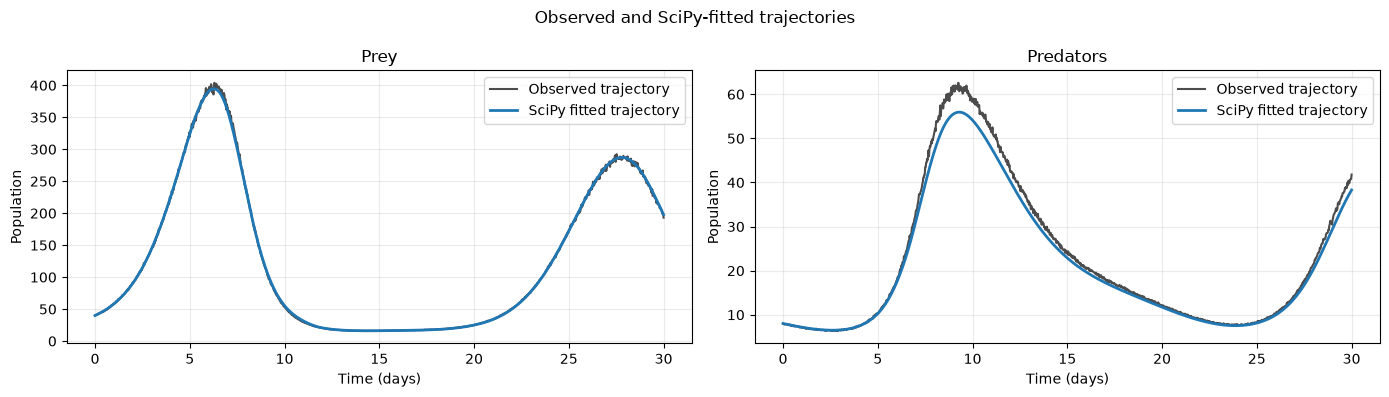

In [28]:
import matplotlib.pyplot as plt
from pybm.estimate.int_scipy import simulate as simulate_scipy

# Simulacija z ocenjenimi SciPy parametri
fitted_solution = simulate_scipy(
    *model.get_endo_variables(),
    t_eval=times,
    const_ctx=const_values,
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharex=True)

series = [
    ("n_prey", "Prey"),
    ("n_predator", "Predators"),
]

for index, (name, title) in enumerate(series):
    ax = axes[index]
    observed = components[name].data.x

    ax.plot(
        times, observed,
        label="Observed trajectory",
        color="black",
        alpha=0.7,
    )
    ax.plot(
        times, fitted_solution.y[index],
        label="SciPy fitted trajectory",
        color="tab:blue",
        linewidth=2,
    )

    ax.set_title(title)
    ax.set_xlabel("Time (days)")
    ax.set_ylabel("Population")
    ax.grid(alpha=0.25)
    ax.legend()

fig.suptitle("Observed and SciPy-fitted trajectories")
fig.tight_layout()
plt.show()

## Torch optimisation (autograd)

In [29]:
from pybm.estimate.int_torch import estimate as estimate_torch
import torch
# set initial values of the constants to good guesses
model.consts["growth_rate_prey"].initial_value = 0.5
model.consts["growth_rate_predator"].initial_value = -0.1
model.consts["predation_rate"].initial_value = 0.05
model.consts["conversion_efficiency"].initial_value = 0.05
# torch - change numpy arrays to torch tensors
for var_name, var in model.vars.items():
    if var.data is not None:
        var.data.to_torch()
# change times to a torch tensor
t_eval = torch.tensor(times, requires_grad=True)
# reshape into (1, n_times)
#t_eval = torch.reshape(t_eval, (1, -1))

In [ ]:
#const_values_torch, loss_torch = estimate_torch(model=model, t_eval=t_eval,
#                                                line_search_fn="strong_wolfe", lr=0.1, max_iter=50,
#                                                tolerance_grad=1e-03, tolerance_change=1e-05)  # verbose=2 for more detailed output
const_values_torch, loss_torch = estimate_torch(model=model, t_eval=t_eval, 
                                                opt="adam", lr=0.01, max_iter=200)  


print("Loss: ", loss_torch)

Loss:  0.9505646730023221


In [31]:
# update model constants with estimated values
for const_name, const in model.consts.items():
    const.initial_value = const_values_torch[const.index_in_ctx].item()

print("\nEstimated values of the constants:")
for const_name, const in model.consts.items():
    print(f"{const_name}: {round(const.initial_value, 2)}, true value: {true_const_values[const_name]}")


Estimated values of the constants:
growth_rate_prey: 0.51, true value: 0.5
growth_rate_predator: -0.11, true value: -0.1
predation_rate: 0.04, true value: 0.02
conversion_efficiency: 0.04, true value: 0.1


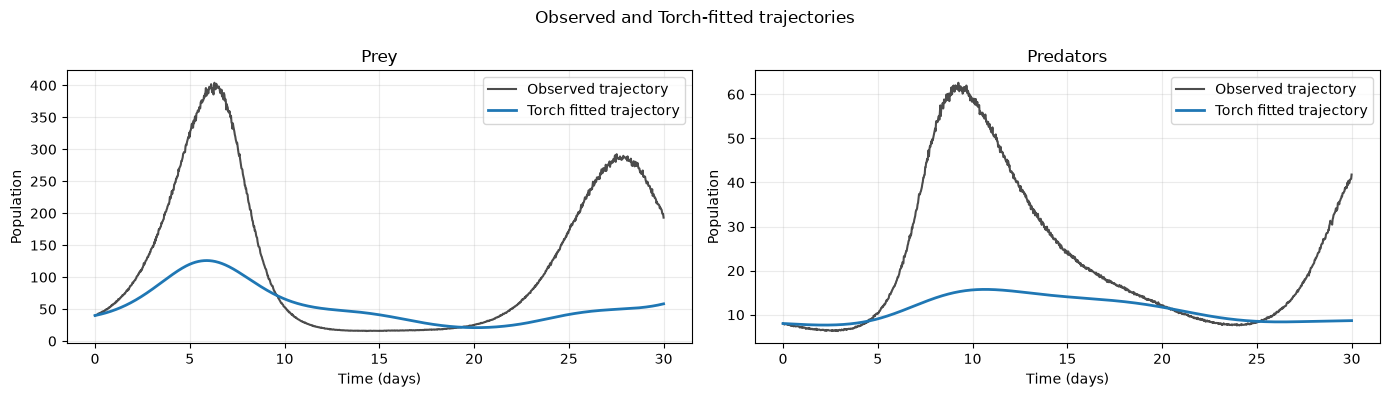

In [32]:
import matplotlib.pyplot as plt
from pybm.estimate.int_scipy import simulate as simulate_scipy

# Simulacija z ocenjenimi SciPy parametri
fitted_solution = simulate_scipy(
    *model.get_endo_variables(),
    t_eval=times,
    const_ctx=const_values_torch,
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharex=True)

series = [
    ("n_prey", "Prey"),
    ("n_predator", "Predators"),
]

for index, (name, title) in enumerate(series):
    ax = axes[index]
    observed = components[name].data.x

    ax.plot(
        times, observed,
        label="Observed trajectory",
        color="black",
        alpha=0.7,
    )
    ax.plot(
        times, fitted_solution.y[index],
        label="Torch fitted trajectory",
        color="tab:blue",
        linewidth=2,
    )

    ax.set_title(title)
    ax.set_xlabel("Time (days)")
    ax.set_ylabel("Population")
    ax.grid(alpha=0.25)
    ax.legend()

fig.suptitle("Observed and Torch-fitted trajectories")
fig.tight_layout()
plt.show()

## If-else inside ODE
PyBM allows arbitrary python code inside ODEs. 

Here we study a simple model of a car.

# TODO 

## Urgent  
- Implement `Process` and `ProcessTemplate`
- Finish induction of models 
- Automatically conver ProBMoT to PyBM code

## Other
- better estimation:
  - Integrate on smaller intervals, continue just if trajectory is good, use priority queue on different models 
  - Stop integration, if the error of integration is too big (no additional knowledge!)
  - if the data is dense, use numerical derivatives for speedup 
- Improved syntax  
